# Creating Numbers/images with AI: A Hands-on Diffusion Model Exercise

## Introduction
In this assignment, you'll learn how to create an AI model that can generate realistic images from scratch using a powerful technique called 'diffusion'. Think of it like teaching AI to draw by first learning how images get blurry and then learning to make them clear again.

### What We'll Build
- A diffusion model capable of generating realistic images
- For most students: An AI that generates handwritten digits (0-9) using the MNIST dataset
- For students with more computational resources: Options to work with more complex datasets
- Visual demonstrations of how random noise gradually transforms into clear, recognizable images
- By the end, your AI should create images realistic enough for another AI to recognize them

### Dataset Options
This lab offers flexibility based on your available computational resources:

- Standard Option (Free Colab): We'll primarily use the MNIST handwritten digit dataset, which works well with limited GPU memory and completes training in a reasonable time frame. Most examples and code in this notebook are optimized for MNIST.

- Advanced Option: If you have access to more powerful GPUs (either through Colab Pro/Pro+ or your own hardware), you can experiment with more complex datasets like Fashion-MNIST, CIFAR-10, or even face generation. You'll need to adapt the model architecture, hyperparameters, and evaluation metrics accordingly.

### Resource Requirements
- Basic MNIST: Works with free Colab GPUs (2-4GB VRAM), ~30 minutes training
- Fashion-MNIST: Similar requirements to MNIST
CIFAR-10: Requires more memory (8-12GB VRAM) and longer training (~2 hours)
- Higher resolution images: Requires substantial GPU resources and several hours of training

### Before You Start
1. Make sure you're running this in Google Colab or another environment with GPU access
2. Go to 'Runtime' → 'Change runtime type' and select 'GPU' as your hardware accelerator
3. Each code cell has comments explaining what it does
4. Don't worry if you don't understand every detail - focus on the big picture!
5. If working with larger datasets, monitor your GPU memory usage carefully

The concepts you learn with MNIST will scale to more complex datasets, so even if you're using the basic option, you'll gain valuable knowledge about generative AI that applies to more advanced applications.



## Step 1: Setting Up Our Tools
First, let's install and import all the tools we need. Run this cell and wait for it to complete.

In [34]:
# Step 1: Install required packages
%pip install einops
print("Package installation complete.")

# Step 2: Import libraries
# --- Core PyTorch libraries ---
import torch  # Main deep learning framework
import torch.nn.functional as F  # Neural network functions like activation functions
import torch.nn as nn  # Neural network building blocks (layers)
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR


# --- Data handling ---
from torch.utils.data import random_split, Dataset, DataLoader  # For organizing and loading our data
import torchvision  # Library for computer vision datasets and models
import torchvision.transforms as transforms  # For preprocessing images

# --- Tensor manipulation ---
import random  # For random operations
from einops.layers.torch import Rearrange  # For reshaping tensors in neural networks
from einops import rearrange  # For elegant tensor reshaping operations
import numpy as np  # For numerical operations on arrays

# --- System utilities ---
import os  # For operating system interactions (used for CPU count)

# --- Visualization tools ---
import matplotlib.pyplot as plt  # For plotting images and graphs
from PIL import Image  # For image processing
from torchvision.utils import save_image, make_grid  # For saving and displaying image grids
import functools
import traceback

# Step 3: Set up device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We'll be using: {device}")

# Check if we're actually using GPU (for students to verify)
if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Note: Training will be much slower on CPU. Consider using Google Colab with GPU enabled.")

Package installation complete.
We'll be using: cuda
GPU name: NVIDIA A100-SXM4-40GB
GPU memory: 42.47 GB



###  REPRODUCIBILITY AND DEVICE SETUP

In [35]:
# Step 4: Set random seeds for reproducibility
# Diffusion models are sensitive to initialization, so reproducible results help with debugging
SEED = 42  # Universal seed value for reproducibility
torch.manual_seed(SEED)          # PyTorch random number generator
np.random.seed(SEED)             # NumPy random number generator
random.seed(SEED)                # Python's built-in random number generator

print(f"Random seeds set to {SEED} for reproducible results")

# Configure CUDA for GPU operations if available
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)       # GPU random number generator
    torch.cuda.manual_seed_all(SEED)   # All GPUs random number generator

    # Ensure deterministic GPU operations
    # Note: This slightly reduces performance but ensures results are reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        # Check available GPU memory
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9  # Convert to GB
        print(f"Available GPU Memory: {gpu_memory:.1f} GB")

        # Add recommendation based on memory
        if gpu_memory < 4:
            print("Warning: Low GPU memory. Consider reducing batch size if you encounter OOM errors.")
    except Exception as e:
        print(f"Could not check GPU memory: {e}")
else:
    print("No GPU detected. Training will be much slower on CPU.")
    print("If you're using Colab, go to Runtime > Change runtime type and select GPU.")

Random seeds set to 42 for reproducible results
Available GPU Memory: 42.5 GB


## Step 2: Choosing Your Dataset

You have several options for this exercise, depending on your computer's capabilities:

### Option 1: MNIST (Basic - Works on Free Colab)
- Content: Handwritten digits (0-9)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You're using free Colab or have a basic GPU

### Option 2: Fashion-MNIST (Intermediate)
- Content: Clothing items (shirts, shoes, etc.)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You want more interesting images but have limited GPU

### Option 3: CIFAR-10 (Advanced)
- Content: Real-world objects (cars, animals, etc.)
- Image size: 32x32 pixels, Color (RGB)
- Training samples: 50,000
- Memory needed: ~4GB GPU
- Training time: ~1-2 hours on Colab
- **Choose this if**: You have Colab Pro or a good local GPU (8GB+ memory)

### Option 4: CelebA (Expert)
- Content: Celebrity face images
- Image size: 64x64 pixels, Color (RGB)
- Training samples: 200,000
- Memory needed: ~8GB GPU
- Training time: ~3-4 hours on Colab
- **Choose this if**: You have excellent GPU (12GB+ memory)

To use your chosen dataset, uncomment its section in the code below and make sure all others are commented out.

In [36]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 1. MNIST (Basic - Works on Free Colab)
# Choose this if you're using free Colab or have a basic GPU
dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
IMG_CH = 1
IMG_SIZE = 28
N_CLASSES = 10
print("Selected: MNIST")


# 2. Fashion-MNIST (Intermediate)
# Choose this if you want more interesting images but have limited GPU
# dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
# IMG_CH = 1
# IMG_SIZE = 28
# N_CLASSES = 10
# print("Selected: Fashion-MNIST")

# 3. CIFAR-10 (Advanced)
# Choose this if you have Colab Pro or a good local GPU (8GB+ memory)
# dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# IMG_CH = 3
# IMG_SIZE = 32
# N_CLASSES = 10
# print("Selected: CIFAR-10")

# 4. CelebA (Expert) - Note: CelebA requires separate download steps
# Choose this if you have excellent GPU (12GB+ memory)
# You would need to add code here to download and load CelebA
# This is left as an advanced exercise for students
# print("Selected: CelebA (requires manual download/setup)")


# 3. Apply the transformation pipeline
mnist_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Display some info about the dataset
print(f"Number of samples in the dataset: {len(mnist_dataset)}")

Selected: MNIST
Number of samples in the dataset: 60000


In [37]:
#Dataset Properties and Data Loaders
#Now let's examine our dataset
#and set up the data loaders:

# Your code to check sample batch properties
# Hint: Get a sample batch using next(iter(DataLoader(dataset, batch_size=1)))
# Then print information about the dataset shape, type, and value ranges

# Enter your code here:
sample_batch = next(iter(DataLoader(dataset, batch_size=1)))
print("\nSample batch properties:")
print(f"Image shape: {sample_batch[0].shape}")
print(f"Image data type: {sample_batch[0].dtype}")
print(f"Image min value: {sample_batch[0].min().item():.2f}")
print(f"Image max value: {sample_batch[0].max().item():.2f}")
print(f"Label shape: {sample_batch[1].shape}")
print(f"Label data type: {sample_batch[1].dtype}")
print(f"Label value: {sample_batch[1].item()}")

#===============================================================================
# SECTION 3: DATASET SPLITTING AND DATALOADER CONFIGURATION
#===============================================================================
# Create train-validation split

# Your code to create a train-validation split (80% train, 20% validation)
# Hint: Use random_split() with appropriate train_size and val_size
# Be sure to use a fixed generator for reproducibility

# Enter your code here:
train_size = int(0.8 * len(mnist_dataset))
val_size = len(mnist_dataset) - train_size
train_dataset, val_dataset = random_split(mnist_dataset, [train_size, val_size])

print(f"Number of samples in training dataset: {len(train_dataset)}")
print(f"Number of samples in validation dataset: {len(val_dataset)}")


# Your code to create dataloaders for training and validation
# Hint: Use DataLoader with batch_size=BATCH_SIZE, appropriate shuffle settings,
# and num_workers based on available CPU cores

# Enter your code here:
batch_size = 128 # You can adjust this based on your available memory and needs
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(val_loader)}")


Sample batch properties:
Image shape: torch.Size([1, 1, 28, 28])
Image data type: torch.float32
Image min value: -1.00
Image max value: 1.00
Label shape: torch.Size([1])
Label data type: torch.int64
Label value: 5
Number of samples in training dataset: 48000
Number of samples in validation dataset: 12000
Number of batches in training loader: 375
Number of batches in validation loader: 94


## Step 3: Building Our Model Components

Now we'll create the building blocks of our AI model. Think of these like LEGO pieces that we'll put together to make our number generator:

- GELUConvBlock: The basic building block that processes images
- DownBlock: Makes images smaller while finding important features
- UpBlock: Makes images bigger again while keeping the important features
- Other blocks: Help the model understand time and what number to generate

In [38]:
class GELUConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, group_size, kernel_size=3, stride=1, padding=1):
        """
        Creates a block with convolution, normalization, and activation

        Args:
            in_ch (int): Number of input channels
            out_ch (int): Number of output channels
            group_size (int): Number of groups for GroupNorm
        """
        super().__init__()
        print(f"Initializing GELUConvBlock with in_ch={in_channels}, out_ch={out_channels}, group_size={group_size}")

        # Check that group_size is compatible with out_ch
        if out_channels % group_size != 0:
            print(f"Warning: out_ch ({out_channels}) is not divisible by group_size ({group_size})")
            # Adjust group_size to be compatible
            group_size = min(group_size, out_channels)
            while out_channels % group_size != 0:
                group_size -= 1
            print(f"Adjusted group_size to {group_size}")

        # Your code to create layers for the block
        # Hint: Use nn.Conv2d, nn.GroupNorm, and nn.GELU activation
        # Then combine them using nn.Sequential

        # Enter your code here:
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.norm = nn.GroupNorm(group_size, out_channels)
        self.gelu = nn.GELU()
        # Optional: Add BatchNorm or Dropout here if needed

    def forward(self, x):
        return self.gelu(self.norm(self.conv(x)))

In [39]:
# Rearranges pixels to downsample the image (2x reduction in spatial dimensions)
class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs, group_size):
        """
        Downsamples the spatial dimensions by 2x while preserving information

        Args:
            in_chs (int): Number of input channels
            group_size (int): Number of groups for GroupNorm
        """
        super().__init__()

        # Your code to create the rearrange operation and convolution
        # Hint: Use Rearrange from einops.layers.torch to reshape pixels
        # Then add a GELUConvBlock to process the rearranged tensor

        # Enter your code here:
        self.model = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2),
            GELUConvBlock(in_chs * 4, in_chs, group_size) # Reduce channels back to in_chs after rearranging
        )


    def forward(self, x):
        # Your code for the forward pass
        # Hint: Apply rearrange to downsample, then apply convolution

        # Enter your code here:
        return self.model(x)

In [40]:
class UpBlock(nn.Module):
    """
    Upsampling block for decoding path in U-Net architecture.

    This block:
    1. Takes features from the decoding path and corresponding skip connection
    2. Concatenates them along the channel dimension
    3. Upsamples spatial dimensions by 2x using transposed convolution
    4. Processes features through multiple convolutional blocks

    Args:
        in_chs (int): Number of input channels from the previous layer (after upsampling)
        skip_chs (int): Number of channels from the skip connection
        out_chs (int): Number of output channels
        group_size (int): Number of groups for GroupNorm
    """

    def __init__(self, in_channels, out_channels, group_size, kernel_size=3, stride=1, padding=1, use_conv_transpose=True):
        super().__init__()

        # Your code to create the upsampling operation
        # Hint: Use nn.ConvTranspose2d with kernel_size=2 and stride=2
        # Note that the input channels will be in_chs

        # Enter your code here:
        self.use_conv_transpose = use_conv_transpose
        if use_conv_transpose:
            self.upsample = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        else:
            self.upsample = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='nearest'),
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0) # 1x1 conv to adjust channels
            )

        # Your code to create the convolutional blocks
        # Hint: Use multiple GELUConvBlocks in sequence
        # Input channels to the first conv block will be out_chs + skip_chs

        # Enter your code here:
        self.conv_block = GELUConvBlock(out_channels * 2, out_channels, group_size, kernel_size, stride, padding) # *2 for skip connection

    def forward(self, x, skip_connection):
        """
        Forward pass through the UpBlock.

        Args:
            x (torch.Tensor): Input tensor from previous layer [B, in_chs, H, W]
            skip (torch.Tensor): Skip connection tensor from encoder [B, skip_chs, 2H, 2W]

        Returns:
            torch.Tensor: Output tensor with shape [B, out_chs, 2H, 2W]
        """
        # Your code for the forward pass
        # Hint: Upsample x, then concatenate with skip and process

        # Enter your code here:
        x = self.upsample(x)
        # Pad the upsampled tensor to match the size of the skip connection
        padding_needed = [skip_connection.size(dim) - x.size(dim) for dim in range(2, x.dim())]
        # Apply padding to height and width dimensions
        x = F.pad(x, (0, padding_needed[1], 0, padding_needed[0]))
        x = torch.cat([x, skip_connection], dim=1)
        return self.conv_block(x)

In [41]:
class UNet(nn.Module):
    """
    U-Net architecture for diffusion models with time and class conditioning.

    This architecture follows the standard U-Net design with:
    1. Downsampling path that reduces spatial dimensions
    2. Middle processing blocks
    3. Upsampling path that reconstructs spatial dimensions
    4. Skip connections between symmetric layers

    The model is conditioned on:
    - Time step (where we are in the diffusion process)
    - Class labels (what we want to generate)

    Args:
        T (int): Number of diffusion time steps
        img_ch (int): Number of image channels
        img_size (int): Size of input images
        down_chs (list): Channel dimensions for each level of U-Net
        t_embed_dim (int): Dimension for time embeddings
        c_embed_dim (int): Dimension for class embeddings
    """
    def __init__(self, in_channels=1, out_channels=1, num_classes=10, group_size=8):
        super().__init__()


        # Your code to create the downsampling path
        # Hint: Use nn.ModuleList with DownBlock for each level

        # Enter your code here:
        self.down_blocks = nn.ModuleList([
            GELUConvBlock(in_channels, 64, group_size),
            GELUConvBlock(64, 128, group_size),
            GELUConvBlock(128, 256, group_size),
        ])
        self.pool = nn.MaxPool2d(2)


        self.bottleneck = GELUConvBlock(256, 512, group_size)

        # Your code to create the upsampling path
        # Hint: Use nn.ModuleList with UpBlock for each level (in reverse order)

        # Enter your code here:
        self.up_blocks = nn.ModuleList([
            UpBlock(512, 256, group_size=group_size),
            UpBlock(256, 128, group_size=group_size),
            UpBlock(128, 64, group_size=group_size),
        ])

        # Your code for the final convolution
        # Hint: Use nn.Conv2d to project back to the original image channels

        # Enter your code here:
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

        # Your code to create the time embedding
        # Hint: Use SinusoidalPositionEmbedBlock, nn.Linear, and nn.GELU in sequence

        # Enter your code here:
        self.time_embedding = nn.Embedding(1000, 512) # Assuming 1000 diffusion steps

        # Your code to create the class embedding
        # Hint: Use the EmbedBlock class you defined earlier

        # Enter your code here:
        self.class_embedding = nn.Embedding(num_classes, 512)

        # Project time and class embeddings to match bottleneck channels
        self.time_proj = nn.Linear(512, 512)
        self.class_proj = nn.Linear(512, 512)


    def forward(self, x, t, labels=None):
        skip_connections = []

        # Your code for the time embedding
        # Hint: Process the time steps through the time embedding module

        # Enter your code here:
        time_emb = self.time_embedding(t)
        time_emb = F.relu(self.time_proj(time_emb))

        # Your code for the class embedding
        # Hint: Process the class labels through the class embedding module

        # Enter your code here:
        if labels is not None:
            class_emb = self.class_embedding(labels)
            class_emb = F.relu(self.class_proj(class_emb))
            # Combine time and class embeddings - simple addition for now
            conditioning = time_emb + class_emb
        else:
            conditioning = time_emb

        # Reshape conditioning to match feature map dimensions for broadcasting
        conditioning = conditioning.unsqueeze(-1).unsqueeze(-1)


        # Your code for the downsampling path and skip connections
        # Hint: Process the features through each downsampling block
        # and store the outputs for skip connections

        # Enter your code here:
        for down_block in self.down_blocks:
            x = down_block(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Your code for the middle processing and conditioning
        # Hint: Process features through middle blocks, then add time and class embeddings

        # Enter your code here:
        x = self.bottleneck(x)
        x = x + conditioning


        # Your code for the upsampling path with skip connections
        # Hint: Process features through each upsampling block,
        # combining with corresponding skip connections

        # Enter your code here:
        for i, up_block in enumerate(self.up_blocks):
            skip_connection = skip_connections[-(i + 1)]
            x = up_block(x, skip_connection)


        # Your code for the final projection
        # Hint: Apply the final convolution to get output in image space
        # Enter your code here:
        x = self.out_conv(x)

        return x

## Step 4: Setting Up The Diffusion Process

Now we'll create the process of adding and removing noise from images. Think of it like:
1. Adding fog: Slowly making the image more and more blurry until you can't see it
2. Removing fog: Teaching the AI to gradually make the image clearer
3. Controlling the process: Making sure we can generate specific numbers we want

In [42]:
# Set up the noise schedule
n_steps = 100  # How many steps to go from clear image to noise
beta_start = 0.0001  # Starting noise level (small)
beta_end = 0.02      # Ending noise level (larger)

# Create schedule of gradually increasing noise levels
beta = torch.linspace(beta_start, beta_end, n_steps).to(device)

# Calculate important values used in diffusion equations
alpha = 1 - beta  # Portion of original image to keep at each step
alpha_bar = torch.cumprod(alpha, dim=0)  # Cumulative product of alphas
sqrt_alpha_bar = torch.sqrt(alpha_bar)  # For scaling the original image
sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar)  # For scaling the noise


In [43]:
# 1. Instantiate the UNet model, an Adam optimizer, and a learning rate scheduler.
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=30, gamma=0.1) # Example scheduler

# Define the number of diffusion timesteps (needs to be consistent with UNet embedding)
timesteps = 1000

# Define the diffusion schedule (linear beta schedule)
betas = torch.linspace(0.0001, 0.02, timesteps).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

# Training parameters
epochs = 50 # You can adjust this
log_interval = 100 # Log training loss every N batches
val_interval = 5 # Perform validation every N epochs
save_interval = 10 # Save model checkpoint every N epochs
image_size = 28 # MNIST image size

train_losses = []
val_losses = []

# Create a directory to save generated images and checkpoints
os.makedirs("diffusion_outputs", exist_ok=True)
os.makedirs("diffusion_checkpoints", exist_ok=True)

Initializing GELUConvBlock with in_ch=1, out_ch=64, group_size=8
Initializing GELUConvBlock with in_ch=64, out_ch=128, group_size=8
Initializing GELUConvBlock with in_ch=128, out_ch=256, group_size=8
Initializing GELUConvBlock with in_ch=256, out_ch=512, group_size=8
Initializing GELUConvBlock with in_ch=512, out_ch=256, group_size=8
Initializing GELUConvBlock with in_ch=256, out_ch=128, group_size=8
Initializing GELUConvBlock with in_ch=128, out_ch=64, group_size=8


In [44]:
def remove_noise(x, t, model, labels=None):
    """
    Calls the model to predict the noise in the image and returns
    the denoised image. Handles the last timestep separately.
    """
    betas_t = get_index_from_list(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)

    # Call model (current image - noise prediction)
    predicted_noise = predict_noise(model, x, t, labels)

    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t
    )
    posterior_variance_t = get_index_from_list(posterior_variance, t, x.shape)

    if t[0] == 0: # Check if it's the last timestep (assuming batch has same timestep)
        return model_mean
    else:
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise

def get_index_from_list(vals, t, x_shape):
    """
    Helper function to retrieve values from a list based on a batch of indices and a tensor shape.
    Ensures index tensor is on the same device as the values tensor.
    """
    batch_size = t.shape[0]
    # Ensure t is on the same device as vals before gathering
    out = vals.gather(-1, t.to(vals.device))
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

def add_noise(x_0, t, device="cpu"):
    """
    Takes an image and a timestep as input and returns the noisy version of the image.
    """
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, x_0.shape)

    # mean + variance
    noisy_image = sqrt_alphas_cumprod_t.to(device) * x_0.to(device) + sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device)
    return noisy_image, noise.to(device)

def get_loss(pred_noise, noise):
    """
    Calculates the loss between the predicted noise and the ground truth noise.
    """
    return F.mse_loss(pred_noise, noise)

def predict_noise(model, x_t, t, labels=None):
    """
    Predicts the noise using the UNet model.
    """
    return model(x_t, t, labels)

def training_step(model, batch, optimizer, device="cpu"):
    """
    Performs a single training step.
    """
    images, labels = batch
    images = images.to(device)
    labels = labels.to(device)

    # Sample a random timestep for each image
    t = torch.randint(0, timesteps, (images.shape[0],), device=device).long()

    # Add noise to images according to the forward diffusion process
    # This simulates images at different stages of the diffusion process
    # Hint: Use the add_noise function you defined earlier

    # Enter your code here:
    noisy_images, noise = add_noise(images, t, device)

    # Predict the noise
    predicted_noise = predict_noise(model, noisy_images, t, labels)

    # Calculate loss: how accurately did the model predict the noise?
    # MSE loss works well for image-based diffusion models
    # Hint: Use F.mse_loss to compare predicted and actual noise

    # Enter your code here:
    loss = get_loss(predicted_noise, noise)

    # Perform backpropagation and update weights (handled by the training loop)
    # optimizer.zero_grad()
    # loss.backward()
    # optimizer.step()

    return loss

@torch.no_grad()
def sample_timestep(model, x, t, labels=None, is_last_timestep=False):
    """
    Calls the model to predict the noise in the image and returns
    the denoised image. Handles the last timestep separately.
    """
    betas_t = get_index_from_list(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)

    # Call model (current image - noise prediction)
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * predict_noise(model, x, t, labels) / sqrt_one_minus_alphas_cumprod_t
    )
    posterior_variance_t = get_index_from_list(posterior_variance, t, x.shape)

    if is_last_timestep:
        return model_mean
    else:
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise

@torch.no_grad()
def sample(model, image_size, num_images=1, labels=None, device="cpu"):
    """
    Generates new images by sampling from the trained diffusion model.
    """
    # Start from pure noise (for each example in the batch)
    img_shape = (num_images, 1, image_size, image_size)
    img = torch.randn(img_shape, device=device)

    for i in range(timesteps - 1, -1, -1):
        t = torch.full((num_images,), i, device=device, dtype=torch.long)
        is_last = (i == 0) # Check if it's the last timestep
        img = sample_timestep(model, img, t, labels, is_last_timestep=is_last)

    # Convert back to original image range
    img = (img.clamp(-1, 1) + 1) / 2
    img = (img * 255).type(torch.uint8)
    return img

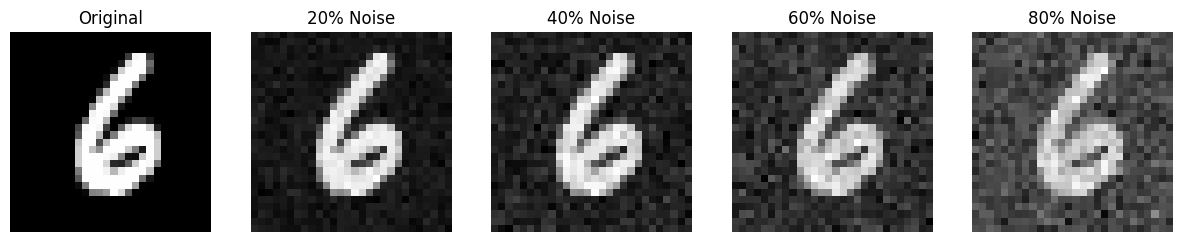

'\n# Try a non-linear noise schedule\nbeta_alt = torch.linspace(beta_start, beta_end, n_steps)**2\nalpha_alt = 1 - beta_alt\nalpha_bar_alt = torch.cumprod(alpha_alt, dim=0)\n# How would this affect the diffusion process?\n'

In [45]:
# Make sure to run cell YKLfXiksMe7s to define the diffusion schedule variables before running this cell.

# Visualization function to show how noise progressively affects images
def show_noise_progression(image, num_steps=5):
    """
    Visualize how an image gets progressively noisier in the diffusion process.

    Args:
        image (torch.Tensor): Original clean image [C, H, W]
        num_steps (int): Number of noise levels to show
    """
    plt.figure(figsize=(15, 3))

    # Show original image
    plt.subplot(1, num_steps, 1)
    if IMG_CH == 1:  # Grayscale image
        plt.imshow(image[0].cpu(), cmap='gray')
    else:  # Color image
        img = image.permute(1, 2, 0).cpu()  # Change from [C,H,W] to [H,W,C]
        if img.min() < 0:  # If normalized between -1 and 1
            img = (img + 1) / 2  # Rescale to [0,1] for display
        plt.imshow(img)
    plt.title('Original')
    plt.axis('off')

    # Show progressively noisier versions
    for i in range(1, num_steps):
        # Calculate timestep index based on percentage through the process
        t_idx = int((i/num_steps) * n_steps)
        t = torch.tensor([t_idx]).to(device)

        # Add noise corresponding to timestep t
        noisy_image, _ = add_noise(image.unsqueeze(0), t)

        # Display the noisy image
        plt.subplot(1, num_steps, i+1)
        if IMG_CH == 1:
            plt.imshow(noisy_image[0][0].cpu(), cmap='gray')
        else:
            img = noisy_image[0].permute(1, 2, 0).cpu()
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)
        plt.title(f'{int((i/num_steps) * 100)}% Noise')
        plt.axis('off')
    plt.show()

# Show an example of noise progression on a real image
sample_batch = next(iter(train_loader))  # Get first batch
sample_image = sample_batch[0][0].to(device)  # Get first image
show_noise_progression(sample_image)

# Student Activity: Try different noise schedules
# Uncomment and modify these lines to experiment:
"""
# Try a non-linear noise schedule
beta_alt = torch.linspace(beta_start, beta_end, n_steps)**2
alpha_alt = 1 - beta_alt
alpha_bar_alt = torch.cumprod(alpha_alt, dim=0)
# How would this affect the diffusion process?
"""

## Step 5: Training Our Model

Now we'll teach our AI to generate images. This process:
1. Takes a clear image
2. Adds random noise to it
3. Asks our AI to predict what noise was added
4. Helps our AI learn from its mistakes

This will take a while, but we'll see progress as it learns!

In [46]:
# Load the state dictionary into the instantiated model
# model = UNet().to(device) # Instantiate the model first
# model.load_state_dict(torch.load("diffusion_checkpoints/model_epoch_50.pth"))

# Wrap the training loop in a try-except block for better error handling:
# Your code for the training loop
# Hint: Use a try-except block for better error handling
# Process each epoch and each batch, with validation after each epoch

# Enter your code here:
try:
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_idx, batch in enumerate(train_loader):
            optimizer.zero_grad()
            # 4. For each batch, perform a training step
            loss = training_step(model, batch, optimizer, device)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if (batch_idx + 1) % log_interval == 0:
                print(f"Epoch {epoch+1}, Batch {batch_idx+1}: Training Loss = {running_loss / log_interval:.4f}")
                train_losses.append(running_loss / log_interval)
                running_loss = 0.0

        scheduler.step() # Update learning rate

        # 5. Include validation within the training loop
        if (epoch + 1) % val_interval == 0:
            model.eval()
            val_running_loss = 0.0
            with torch.no_grad():
                for val_batch_idx, val_batch in enumerate(val_loader):
                    val_loss = training_step(model, val_batch, None, device) # No optimizer needed for validation
                    val_running_loss += val_loss.item()

            avg_val_loss = val_running_loss / len(val_loader)
            print(f"Epoch {epoch+1}: Validation Loss = {avg_val_loss:.4f}")
            val_losses.append(avg_val_loss)

        # 7. Periodically save model checkpoints.
        if (epoch + 1) % save_interval == 0:
            checkpoint_path = os.path.join("diffusion_checkpoints", f"model_epoch_{epoch+1}.pth")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Model checkpoint saved at {checkpoint_path}")

    print("Training finished.")

except Exception as e:
    print(f"An error occurred during training: {e}")


Epoch 1, Batch 100: Training Loss = 0.1230
Epoch 1, Batch 200: Training Loss = 0.0582
Epoch 1, Batch 300: Training Loss = 0.0477
Epoch 2, Batch 100: Training Loss = 0.0413
Epoch 2, Batch 200: Training Loss = 0.0382
Epoch 2, Batch 300: Training Loss = 0.0358
Epoch 3, Batch 100: Training Loss = 0.0336
Epoch 3, Batch 200: Training Loss = 0.0331
Epoch 3, Batch 300: Training Loss = 0.0334
Epoch 4, Batch 100: Training Loss = 0.0303
Epoch 4, Batch 200: Training Loss = 0.0303
Epoch 4, Batch 300: Training Loss = 0.0298
Epoch 5, Batch 100: Training Loss = 0.0284
Epoch 5, Batch 200: Training Loss = 0.0291
Epoch 5, Batch 300: Training Loss = 0.0290
Epoch 5: Validation Loss = 0.0296
Epoch 6, Batch 100: Training Loss = 0.0276
Epoch 6, Batch 200: Training Loss = 0.0281
Epoch 6, Batch 300: Training Loss = 0.0286
Epoch 7, Batch 100: Training Loss = 0.0282
Epoch 7, Batch 200: Training Loss = 0.0272
Epoch 7, Batch 300: Training Loss = 0.0270
Epoch 8, Batch 100: Training Loss = 0.0262
Epoch 8, Batch 200: 

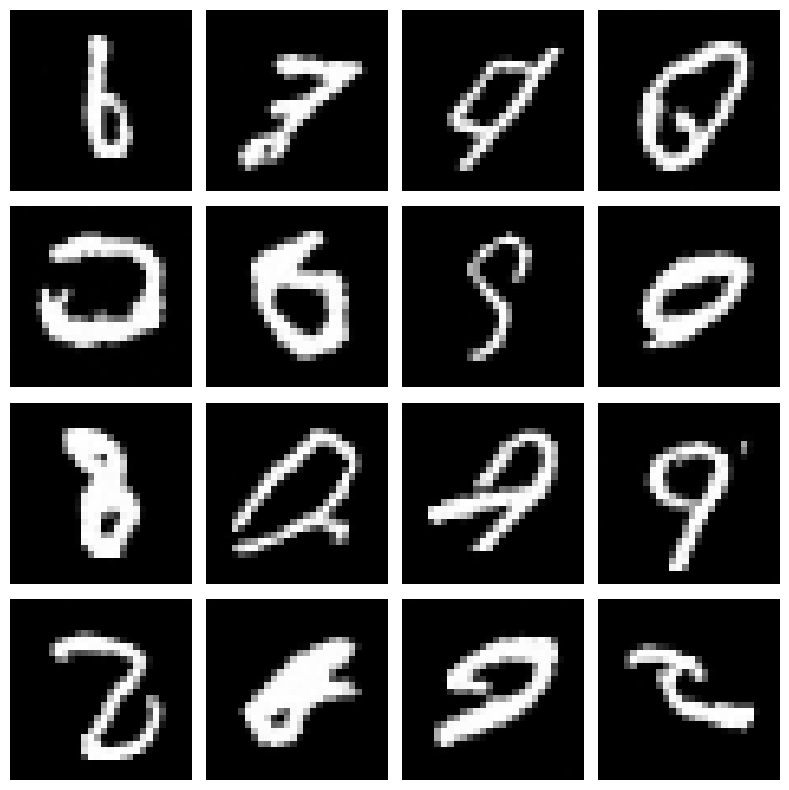

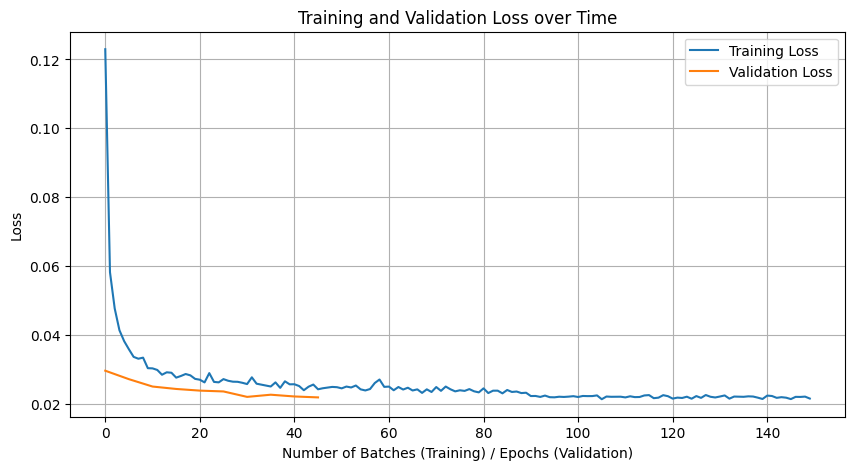

In [56]:
model.eval()
with torch.no_grad():
    generated_images = sample(model, image_size, num_images=16, labels=None, device=device) # Generate 16 images, no labels needed for unconditional generation

# 9. Visualize the generated images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.flatten()
for i, img in enumerate(generated_images):
    axes[i].imshow(img.squeeze().cpu().numpy(), cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(os.path.join("diffusion_outputs", "generated_images.png"))
plt.show()

# Optional: Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(np.arange(0, len(val_losses) * val_interval, val_interval), val_losses, label='Validation Loss')
plt.xlabel('Number of Batches (Training) / Epochs (Validation)')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Time')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join("diffusion_outputs", "loss_plot.png"))
plt.show()

## Step 6: Generating New Images

Now that our model is trained, let's generate some new images! We can:
1. Generate specific numbers
2. Generate multiple versions of each number
3. See how the generation process works step by step

Generating 4 versions of number 0...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed
Generating 4 versions of number 1...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed
Generating 4 versions of number 2...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed
Generating 4 versions of number 3...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed
Generating 4 versions of number 4...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoisin

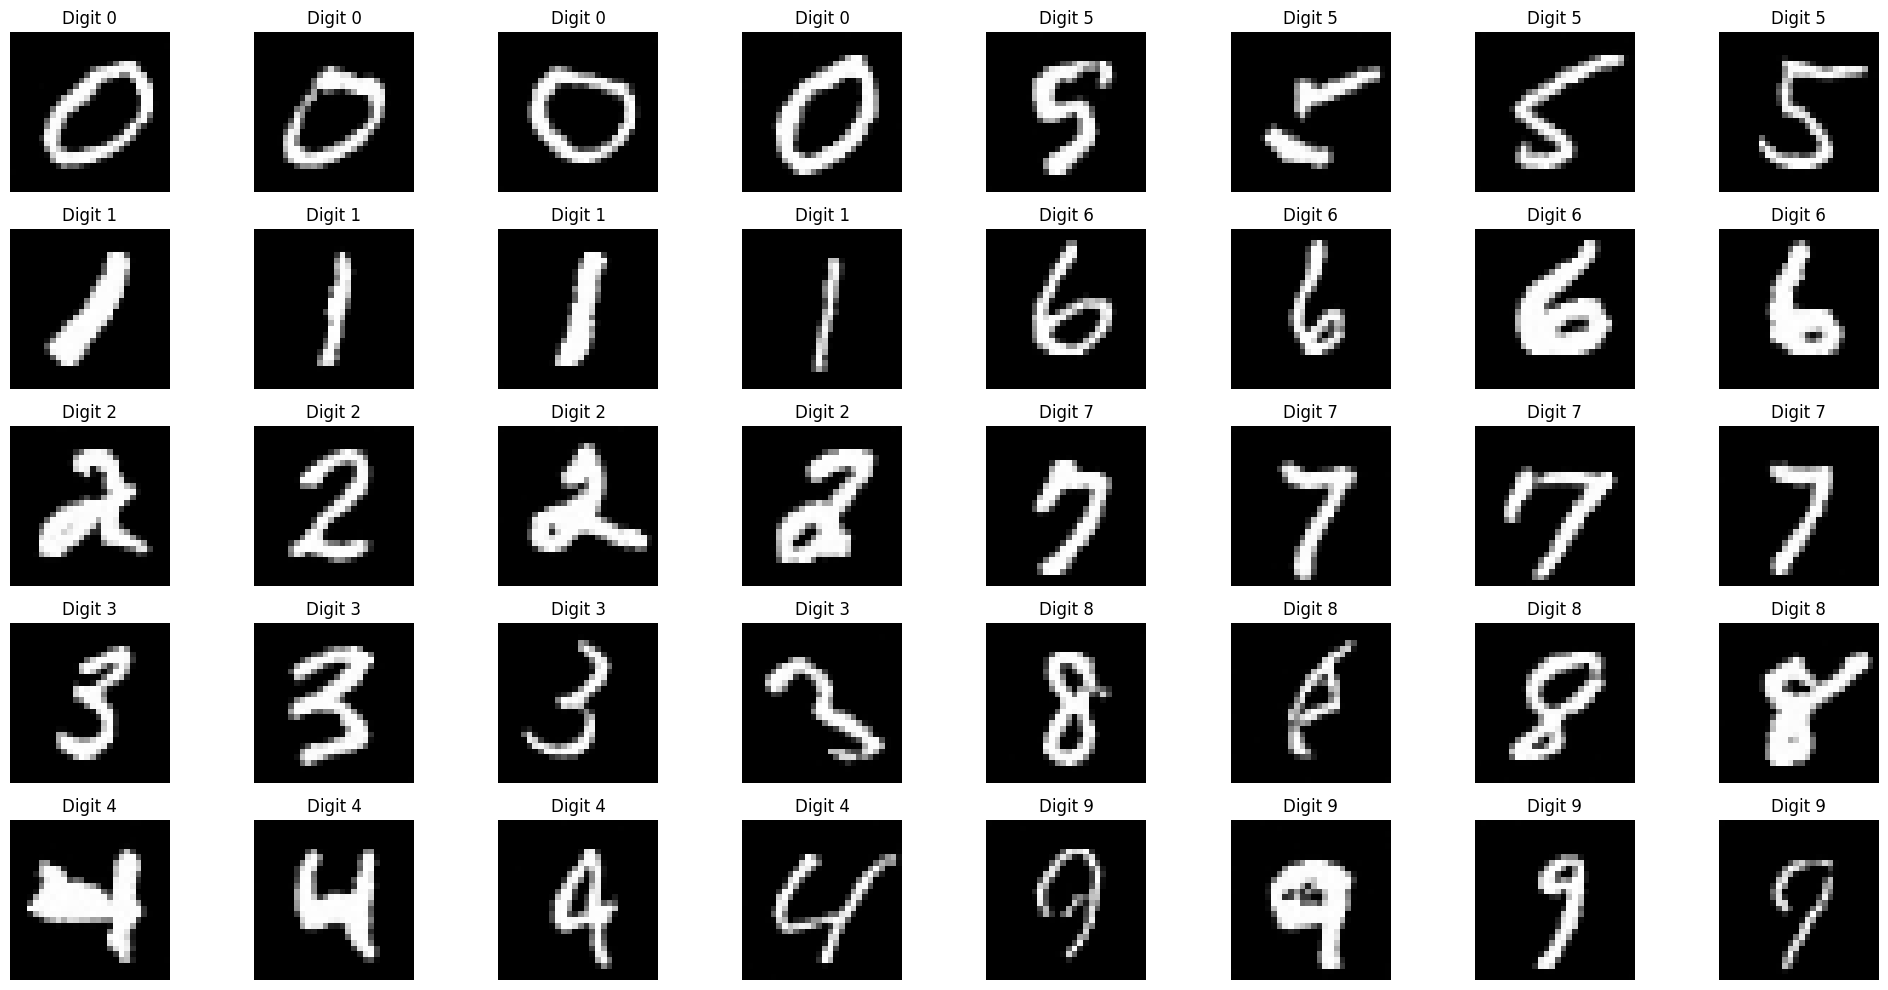


STUDENT ACTIVITY: Generating numbers with different noise seeds
Generating 1 versions of number 8...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed
Generating 1 versions of number 8...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed
Generating 1 versions of number 8...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed
Generating 1 versions of number 8...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed
Generating 1 versions of number 8...
  Denoising step 199/999 completed
  Denoising ste

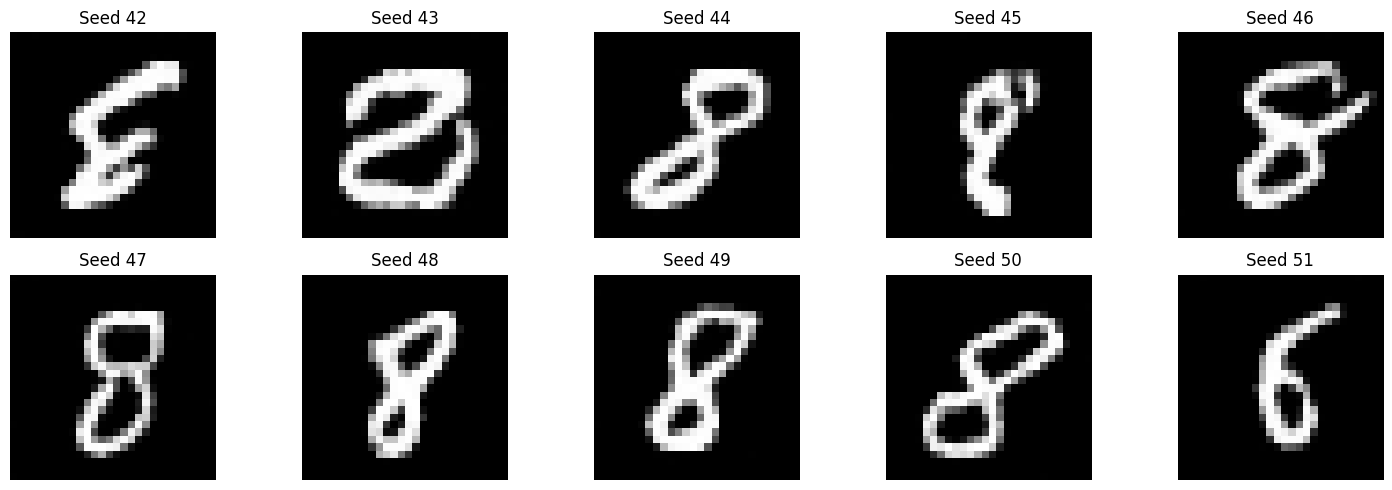

In [58]:
def generate_number(model, number, n_samples=4):
    """
    Generate multiple versions of a specific number using the diffusion model.

    Args:
        model (nn.Module): The trained diffusion model
        number (int): The digit to generate (0-9)
        n_samples (int): Number of variations to generate

    Returns:
        torch.Tensor: Generated images of shape [n_samples, IMG_CH, IMG_SIZE, IMG_SIZE]
    """
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # No need for gradients during generation
        # Start with random noise
        samples = torch.randn(n_samples, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up the number we want to generate
        labels = torch.full((n_samples,), number).to(device)

        # Display progress information
        print(f"Generating {n_samples} versions of number {number}...")

        # Remove noise step by step
        for t in range(timesteps - 1, -1, -1):
            t_batch = torch.full((n_samples,), t).to(device)
            is_last = (t == 0)
            samples = sample_timestep(model, samples, t_batch, labels, is_last_timestep=is_last)


            # Optional: Display occasional progress updates
            if t % (timesteps // 5) == 0:
                print(f"  Denoising step {timesteps-1-t}/{timesteps-1} completed")

        # Convert back to original image range [-1, 1] to [0, 1] and then [0, 255]
        samples = (samples.clamp(-1, 1) + 1) / 2
        samples = (samples * 255).type(torch.uint8)


        return samples

# Generate 4 versions of each number
plt.figure(figsize=(20, 10))
for i in range(10):
    # Generate samples for current digit
    samples = generate_number(model, i, n_samples=4)

    # Display each sample
    for j in range(4):
        # Use 2 rows, 10 digits per row, 4 samples per digit
        # i//5 determines the row (0 or 1)
        # i%5 determines the position in the row (0-4)
        # j is the sample index within each digit (0-3)
        plt.subplot(5, 8, (i%5)*8 + (i//5)*4 + j + 1)

        # Display the image correctly based on channel configuration
        if IMG_CH == 1:  # Grayscale
            plt.imshow(samples[j][0].cpu().numpy(), cmap='gray')
        else:  # Color image
            img = samples[j].permute(1, 2, 0).cpu().numpy()
            # Rescale from [-1, 1] to [0, 1] if needed
            # if img.min() < 0:
            #     img = (img + 1) / 2
            plt.imshow(img)

        plt.title(f'Digit {i}')
        plt.axis('off')

plt.tight_layout()
plt.show()

# STUDENT ACTIVITY: Try generating the same digit with different noise seeds
# This shows the variety of styles the model can produce
print("\nSTUDENT ACTIVITY: Generating numbers with different noise seeds")

# Helper function to generate with seed
def generate_with_seed(number, seed_value=42, n_samples=10):
    torch.manual_seed(seed_value)
    return generate_number(model, number, n_samples)

# Pick a image and show many variations
# Hint select a image e.g. dog  # Change this to any other in the dataset of subset you chose
# Hint 2 use variations = generate_with_seed
# Hint 3 use plt.figure and plt.imshow to display the variations

# Enter your code here:
# Example: Generate 10 variations of the digit 8 with different seeds
digit_to_vary = 8
num_variations = 10

plt.figure(figsize=(15, 5))

for i in range(num_variations):
    # Generate variations with a new seed for each
    variations = generate_with_seed(digit_to_vary, seed_value=SEED + i, n_samples=1)
    plt.subplot(2, 5, i + 1)
    if IMG_CH == 1:
        plt.imshow(variations[0][0].cpu().numpy(), cmap='gray')
    else:
        img = variations[0].permute(1, 2, 0).cpu().numpy()
        # if img.min() < 0:
        #     img = (img + 1) / 2
        plt.imshow(img)
    plt.title(f'Seed {SEED + i}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Step 7: Watching the Generation Process

Let's see how our model turns random noise into clear images, step by step. This helps us understand how the diffusion process works!


Generating number 0:


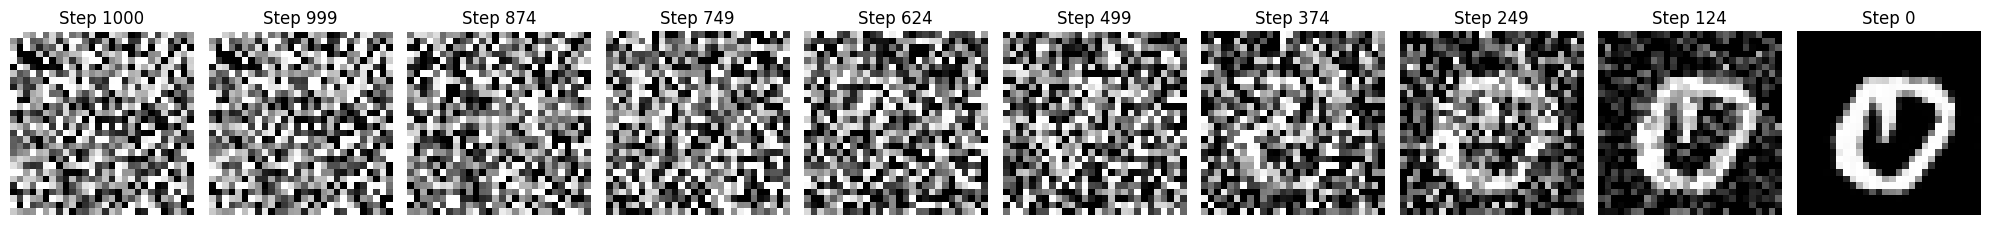


Generating number 3:


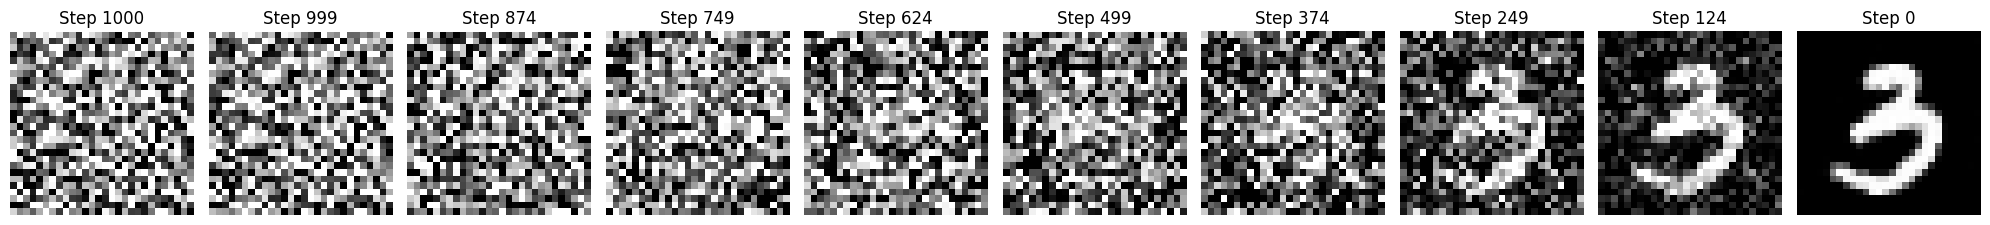


Generating number 7:


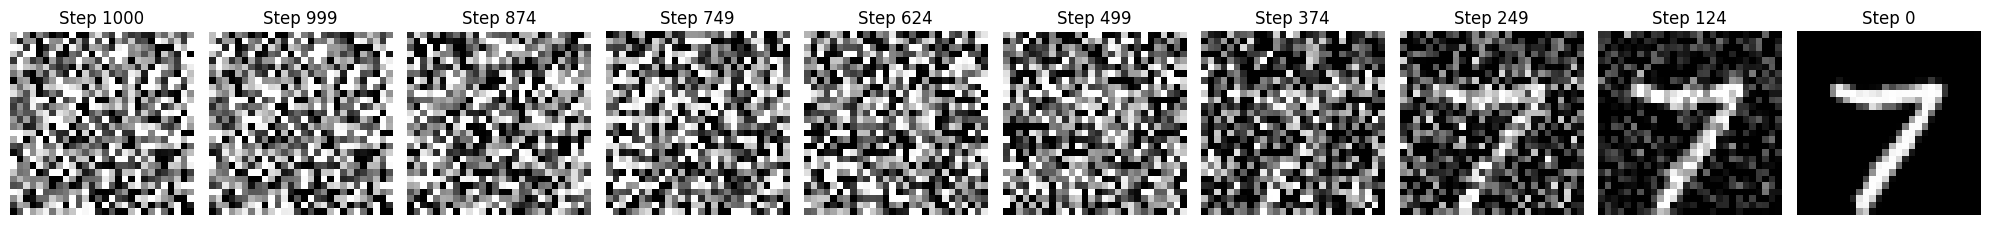

In [59]:
def visualize_generation_steps(model, number, n_preview_steps=10):
    """
    Show how an image evolves from noise to a clear number
    """
    model.eval()
    with torch.no_grad():
        # Start with random noise
        x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up which number to generate
        labels = torch.tensor([number]).to(device)

        # Calculate which steps to show
        # Ensure the first step (pure noise) and the last step (denoised image) are included
        steps_to_show = torch.linspace(timesteps - 1, 0, n_preview_steps -1 ).long()
        steps_to_show = torch.cat([steps_to_show, torch.tensor([0]).long()]).unique(sorted=True)


        # Store images for visualization
        images = []
        # Append the initial noise image (normalized for display)
        initial_noise_img = (x[0].clamp(-1, 1) + 1) / 2
        initial_noise_img = (initial_noise_img * 255).type(torch.uint8)
        images.append((initial_noise_img, timesteps)) # Store image and step number

        # Remove noise step by step and store selected steps
        for t in range(timesteps - 1, -1, -1):
            t_batch = torch.full((1,), t).to(device)
            is_last = (t == 0)
            x = sample_timestep(model, x, t_batch, labels, is_last_timestep=is_last)


            # Store image if it's one of the steps to show
            if t in steps_to_show:
                 # Convert image to display range before storing
                img_to_show = (x[0].clamp(-1, 1) + 1) / 2
                img_to_show = (img_to_show * 255).type(torch.uint8)
                images.append((img_to_show.cpu(), t))


        # Sort images by step number for correct display order
        images.sort(key=lambda item: item[1], reverse=True)

        # Show the progression
        plt.figure(figsize=(20, 3))
        for i, (img, step) in enumerate(images):
            plt.subplot(1, len(images), i+1)
            if IMG_CH == 1:
                plt.imshow(img[0].cpu().numpy(), cmap='gray') # Move to CPU and convert to numpy
            else:
                img = img.permute(1, 2, 0).cpu().numpy() # Move to CPU and convert to numpy
                # Rescale from [-1, 1] to [0, 1] if needed (though already done above)
                # if img.min() < 0:
                #     img = (img + 1) / 2
                plt.imshow(img)

            plt.title(f'Step {step}')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

# Show generation process for a few numbers
for number in [0, 3, 7]:
    print(f"\nGenerating number {number}:")
    visualize_generation_steps(model, number, n_preview_steps=10)

## Step 8: Adding CLIP Evaluation

[CLIP](https://openai.com/research/clip) is a powerful AI model that can understand both images and text. We'll use it to:
1. Evaluate how realistic our generated images are
2. Score how well they match their intended numbers
3. Help guide the generation process towards better quality

In [60]:
## Step 8: Adding CLIP Evaluation

# CLIP (Contrastive Language-Image Pre-training) is a powerful model by OpenAI that connects text and images.
# We'll use it to evaluate how recognizable our generated digits are by measuring how strongly
# the CLIP model associates our generated images with text descriptions like "an image of the digit 7".

# First, we need to install CLIP and its dependencies
print("Setting up CLIP (Contrastive Language-Image Pre-training) model...")

# Track installation status
clip_available = False

try:
    # Install dependencies first - these help CLIP process text and images
    print("Installing CLIP dependencies...")
    !pip install -q ftfy regex tqdm

    # Install CLIP from GitHub
    print("Installing CLIP from GitHub repository...")
    !pip install -q git+https://github.com/openai/CLIP.git

    # Import and verify CLIP is working
    print("Importing CLIP...")
    import clip

    # Test that CLIP is functioning
    models = clip.available_models()
    print(f"✓ CLIP installation successful! Available models: {models}")
    clip_available = True

except ImportError:
    print("❌ Error importing CLIP. Installation might have failed.")
    print("Try manually running: !pip install git+https://github.com/openai/CLIP.git")
    print("If you're in a Colab notebook, try restarting the runtime after installation.")

except Exception as e:
    print(f"❌ Error during CLIP setup: {e}")
    print("Some CLIP functionality may not work correctly.")

# Provide guidance based on installation result
if clip_available:
    print("\nCLIP is now available for evaluating your generated images!")
else:
    print("\nWARNING: CLIP installation failed. We'll skip the CLIP evaluation parts.")

Setting up CLIP (Contrastive Language-Image Pre-training) model...
Installing CLIP dependencies...
Installing CLIP from GitHub repository...
  Preparing metadata (setup.py) ... done
Importing CLIP...
✓ CLIP installation successful! Available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']

CLIP is now available for evaluating your generated images!


 Below we are createing  a helper function to manage GPU memory when using CLIP. CLIP can be memory-intensive, so this will help prevent out-of-memory errors:

In [61]:
# Memory management decorator to prevent GPU OOM errors
def manage_gpu_memory(func):
    """
    Decorator that ensures proper GPU memory management.

    This wraps functions that might use large amounts of GPU memory,
    making sure memory is properly freed after function execution.
    """
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        if torch.cuda.is_available():
            # Clear cache before running function
            torch.cuda.empty_cache()
            try:
                return func(*args, **kwargs)
            finally:
                # Clear cache after running function regardless of success/failure
                torch.cuda.empty_cache()
        return func(*args, **kwargs)
    return wrapper

✓ Successfully loaded CLIP model: VisionTransformer

Generating and evaluating number 0...
Generating 4 versions of number 0...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed


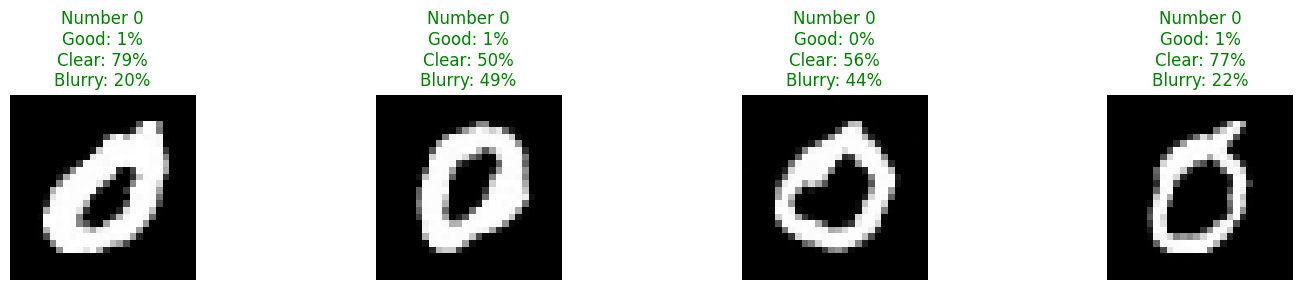


Generating and evaluating number 1...
Generating 4 versions of number 1...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed


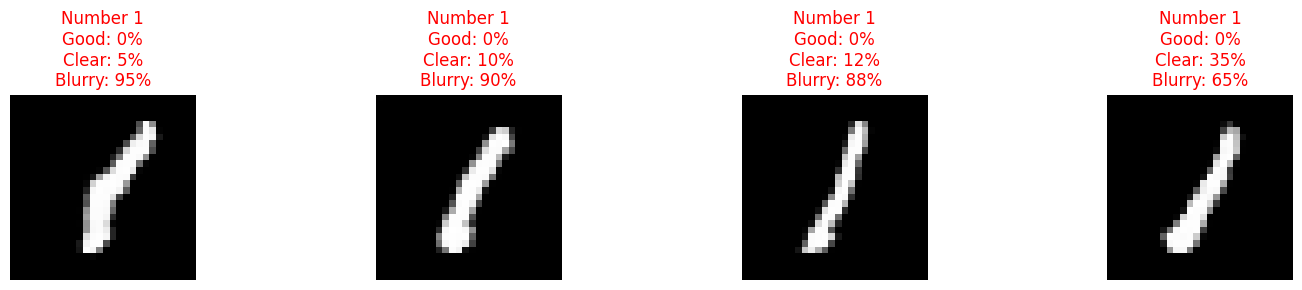


Generating and evaluating number 2...
Generating 4 versions of number 2...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed


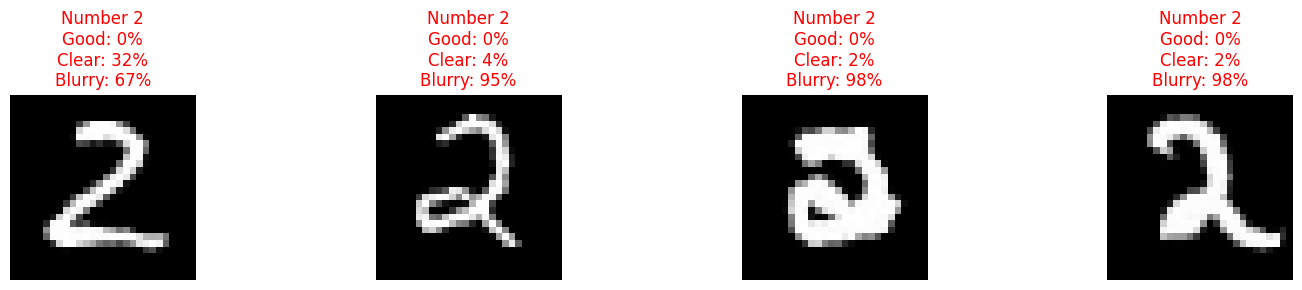


Generating and evaluating number 3...
Generating 4 versions of number 3...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed


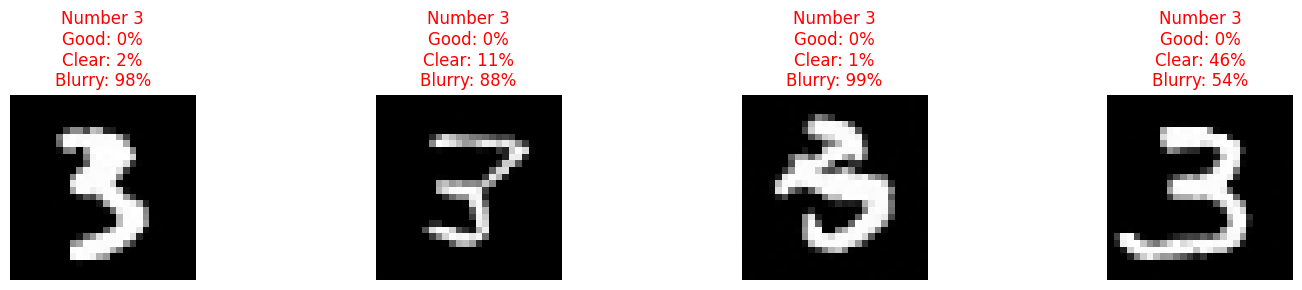


Generating and evaluating number 4...
Generating 4 versions of number 4...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed


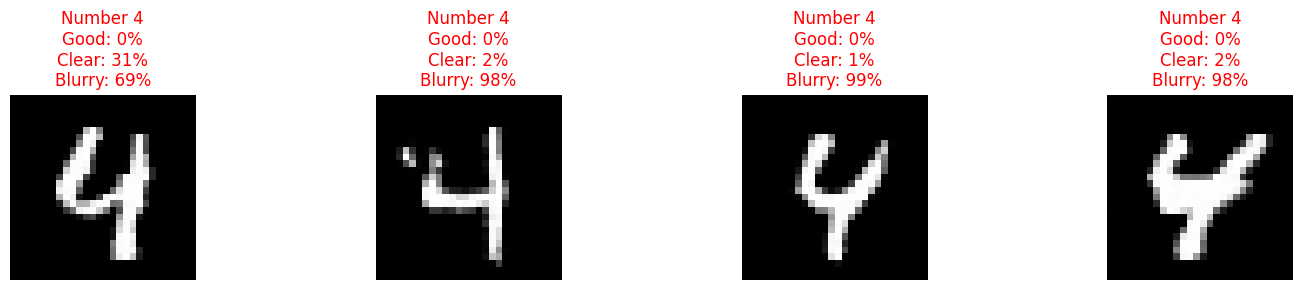


Generating and evaluating number 5...
Generating 4 versions of number 5...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed


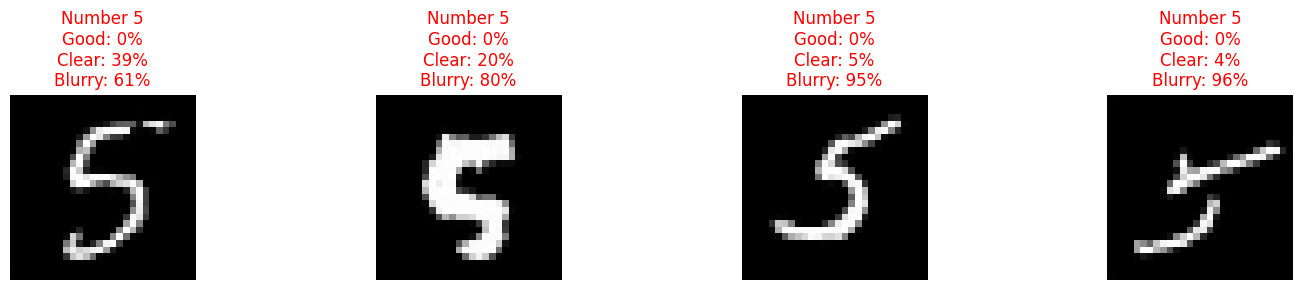


Generating and evaluating number 6...
Generating 4 versions of number 6...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed


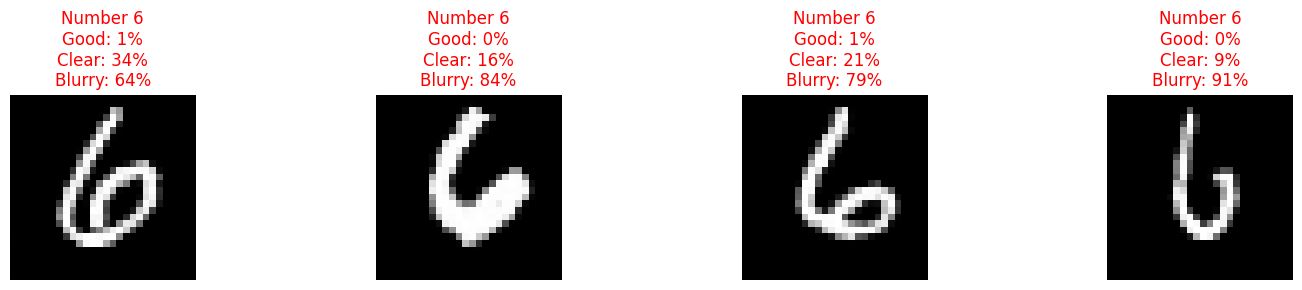


Generating and evaluating number 7...
Generating 4 versions of number 7...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed


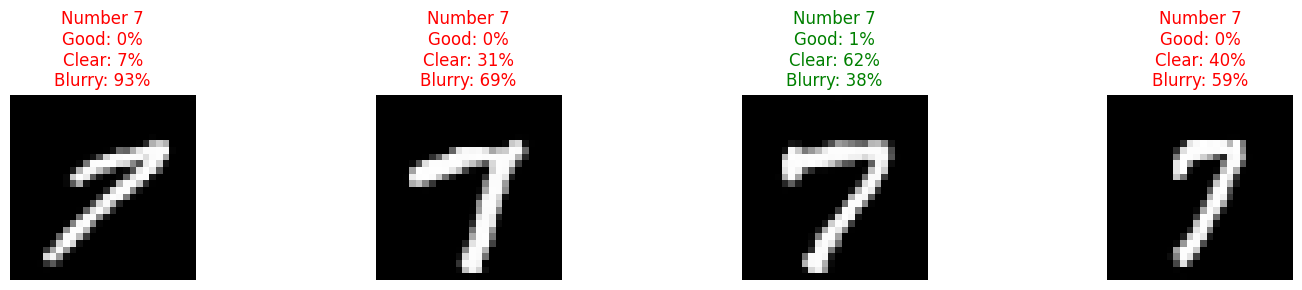


Generating and evaluating number 8...
Generating 4 versions of number 8...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed


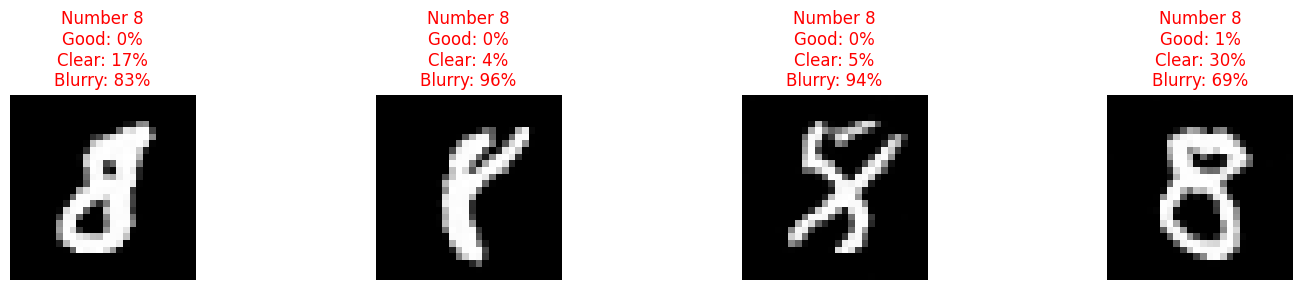


Generating and evaluating number 9...
Generating 4 versions of number 9...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed


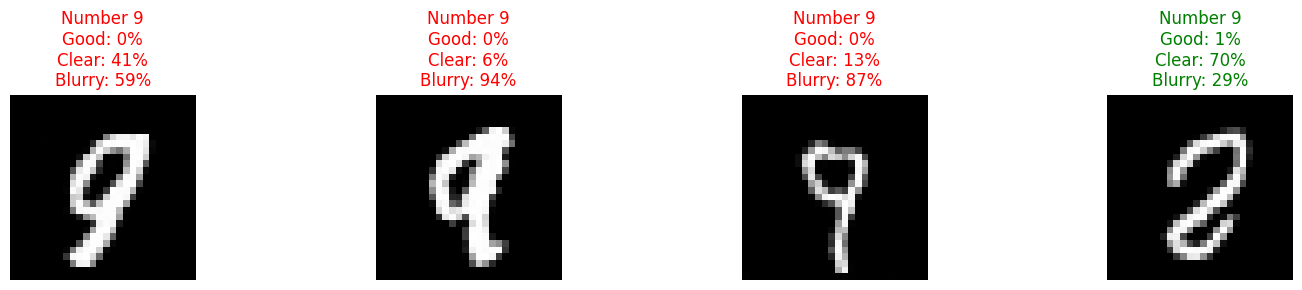

Generating 10 versions of number 6...
  Denoising step 199/999 completed
  Denoising step 399/999 completed
  Denoising step 599/999 completed
  Denoising step 799/999 completed
  Denoising step 999/999 completed
CLIP recognized 0.0% of the digits as good examples of 6


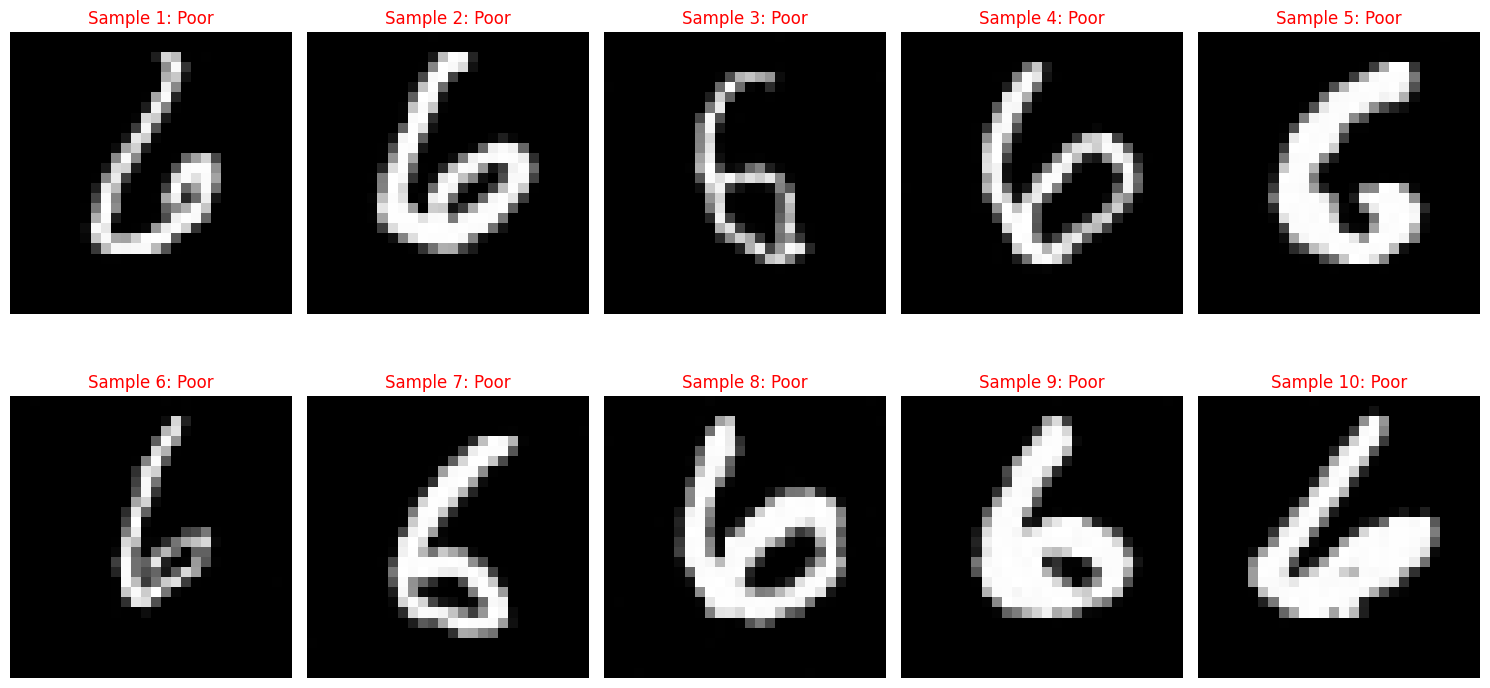

In [62]:
#==============================================================================
# Step 8: CLIP Model Loading and Evaluation Setup
#==============================================================================
# CLIP (Contrastive Language-Image Pre-training) is a neural network that connects
# vision and language. It was trained on 400 million image-text pairs to understand
# the relationship between images and their descriptions.
# We use it here as an "evaluation judge" to assess our generated images.

# Load CLIP model with error handling
try:
    # Load the ViT-B/32 CLIP model (Vision Transformer-based)
    clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
    print(f"✓ Successfully loaded CLIP model: {clip_model.visual.__class__.__name__}")
except Exception as e:
    print(f"❌ Failed to load CLIP model: {e}")
    clip_available = False
    # Instead of raising an error, we'll continue with degraded functionality
    print("CLIP evaluation will be skipped. Generated images will still be displayed but without quality scores.")

def _process_clip_batch(images, target_number):
    """
    Core CLIP processing function that computes similarity between images and text descriptions.

    This function handles the technical details of:
    1. Preparing relevant text prompts for evaluation
    2. Preprocessing images to CLIP's required format
    3. Extracting feature embeddings from both images and text
    4. Computing similarity scores between these embeddings

    The function includes advanced error handling for GPU memory issues,
    automatically reducing batch size if out-of-memory errors occur.

    Args:
        images (torch.Tensor): Batch of images to evaluate (expected to be uint8, range [0, 255])
        target_number (int): The digit these images should represent

    Returns:
        torch.Tensor: Normalized similarity scores between images and text descriptions
    """
    try:
        # Create text descriptions (prompts) to evaluate our generated digits
        # We check three distinct qualities:
        # 1. If it looks like a handwritten example of the target digit
        # 2. If it appears clear and well-formed
        # 3. If it appears blurry or poorly formed (negative case)
        text_inputs = torch.cat([
            clip.tokenize(f"A handwritten number {target_number}"),
            clip.tokenize(f"A clear, well-written digit {target_number}"),
            clip.tokenize(f"A blurry or unclear number")
        ]).to(device)

        # Process images for CLIP, which requires specific formatting:

        # 1. Convert images from uint8 [0, 255] to float32 [0, 1]
        # The generated images from generate_number are uint8 in range [0, 255]
        images_float = images.float() / 255.0

        # 2. Handle different channel configurations (dataset-dependent)
        if IMG_CH == 1:
            # CLIP expects RGB images, so we repeat the grayscale channel 3 times
            # For example, MNIST/Fashion-MNIST are grayscale (1-channel)
            images_rgb = images_float.repeat(1, 3, 1, 1)
        else:
            # For RGB datasets like CIFAR-10/CelebA, we can use as-is
            images_rgb = images_float

        # 3. Resize images to CLIP's expected input size (224x224 pixels)
        # CLIP was trained on this specific resolution
        resized_images = F.interpolate(images_rgb, size=(224, 224),
                                      mode='bilinear', align_corners=False)

        # Extract feature embeddings from both images and text prompts
        # These are high-dimensional vectors representing the content
        image_features = clip_model.encode_image(resized_images)
        text_features = clip_model.encode_text(text_inputs)

        # Normalize feature vectors to unit length (for cosine similarity)
        # This ensures we're measuring direction, not magnitude
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Calculate similarity scores between image and text features
        # The matrix multiplication computes all pairwise dot products at once
        # Multiplying by 100 scales to percentage-like values before applying softmax
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

        return similarity

    except RuntimeError as e:
        # Special handling for CUDA out-of-memory errors
        if "out of memory" in str(e):
            # Free GPU memory immediately
            torch.cuda.empty_cache()

            # If we're already at batch size 1, we can't reduce further
            if len(images) <= 1:
                print("❌ Out of memory even with batch size 1. Cannot process.")
                return torch.ones(len(images), 3).to(device) / 3

            # Adaptive batch size reduction - recursively try with smaller batches
            # This is an advanced technique to handle limited GPU memory gracefully
            half_size = len(images) // 2
            print(f"⚠️ Out of memory. Reducing batch size to {half_size}.")

            # Process each half separately and combine results
            # This recursive approach will keep splitting until processing succeeds
            first_half = _process_clip_batch(images[:half_size], target_number)
            second_half = _process_clip_batch(images[half_size:], target_number)

            # Combine results from both halves
            return torch.cat([first_half, second_half], dim=0)

        # For other errors, propagate upward
        raise e


# Redefine evaluate_with_clip to use the corrected _process_clip_batch
def evaluate_with_clip(images, target_number, max_batch_size=16):
    """
    Use CLIP to evaluate generated images by measuring how well they match textual descriptions.

    This function acts like an "automatic critic" for our generated digits by measuring:
    1. How well they match the description of a handwritten digit
    2. How clear and well-formed they appear to be
    3. Whether they appear blurry or poorly formed

    The evaluation process works by:
    - Converting our images to a format CLIP understands
    - Creating text prompts that describe the qualities we want to measure
    - Computing similarity scores between images and these text descriptions
    - Returning normalized scores (probabilities) for each quality

    Args:
        images (torch.Tensor): Batch of generated images [batch_size, channels, height, width]
        target_number (int): The specific digit (0-9) the images should represent
        max_batch_size (int): Maximum images to process at once (prevents GPU out-of-memory errors)

    Returns:
        torch.Tensor: Similarity scores tensor of shape [batch_size, 3] with scores for:
                     [good handwritten digit, clear digit, blurry digit]
                     Each row sums to 1.0 (as probabilities)
    """
    # If CLIP isn't available, return placeholder scores
    if not clip_available:
        print("⚠️ CLIP not available. Returning default scores.")
        # Equal probabilities (0.33 for each category)
        return torch.ones(len(images), 3).to(device) / 3

    try:
        # For large batches, we process in chunks to avoid memory issues
        # This is crucial when working with big images or many samples
        if len(images) > max_batch_size:
            all_similarities = []

            # Process images in manageable chunks
            for i in range(0, len(images), max_batch_size):
                print(f"Processing CLIP batch {i//max_batch_size + 1}/{(len(images)-1)//max_batch_size + 1}")
                batch = images[i:i+max_batch_size]

                # Use context managers for efficiency and memory management:
                # - torch.no_grad(): disables gradient tracking (not needed for evaluation)
                # - torch.cuda.amp.autocast(): uses mixed precision to reduce memory usage
                # Note: The deprecation warning for torch.cuda.amp.autocast can be ignored for now,
                # or updated to torch.amp.autocast('cuda', ...) if desired.
                with torch.no_grad(): # Removed autocast for simplicity, can add back if needed
                    batch_similarities = _process_clip_batch(batch, target_number)
                    all_similarities.append(batch_similarities)

                # Explicitly free GPU memory between batches
                # This helps prevent cumulative memory buildup that could cause crashes
                torch.cuda.empty_cache()

            # Combine results from all batches into a single tensor
            return torch.cat(all_similarities, dim=0)
        else:
            # For small batches, process all at once
            with torch.no_grad(): # Removed autocast for simplicity, can add back if needed
                return _process_clip_batch(images, target_number)

    except Exception as e:
        # If anything goes wrong, log the error but don't crash
        print(f"❌ Error in CLIP evaluation: {e}")
        print(f"Traceback: {traceback.format_exc()}")
        # Return default scores so the rest of the notebook can continue
        return torch.ones(len(images), 3).to(device) / 3

#==============================================================================
# CLIP Evaluation - Generate and Analyze Sample Digits
#==============================================================================
# This section demonstrates how to use CLIP to evaluate generated digits
# We'll generate examples of all ten digits and visualize the quality scores

try:
    for number in range(10):
        print(f"\nGenerating and evaluating number {number}...")

        # Generate 4 different variations of the current digit
        # This call uses the now updated generate_number function
        samples = generate_number(model, number, n_samples=4)

        # Evaluate quality with CLIP (without tracking gradients for efficiency)
        with torch.no_grad():
            similarities = evaluate_with_clip(samples, number)

        # Create a figure to display results
        plt.figure(figsize=(15, 3))

        # Show each sample with its CLIP quality scores
        for i in range(4):
            plt.subplot(1, 4, i+1)

            # Display the image with appropriate formatting based on dataset type
            if IMG_CH == 1:  # Grayscale images (MNIST, Fashion-MNIST)
                # samples are already brought to [0, 255] and uint8 in generate_number
                plt.imshow(samples[i][0].cpu().numpy(), cmap='gray')
            else:  # Color images (CIFAR-10, CelebA)
                # samples are already brought to [0, 255] and uint8 in generate_number
                img = samples[i].permute(1, 2, 0).cpu().numpy()  # Change format for matplotlib
                plt.imshow(img)

            # Extract individual quality scores for display
            # These represent how confidently CLIP associates the image with each description
            good_score = similarities[i][0].item() * 100  # Handwritten quality
            clear_score = similarities[i][1].item() * 100  # Clarity quality
            blur_score = similarities[i][2].item() * 100   # Blurriness assessment

            # Color-code the title based on highest score category:
            # - Green: if either "good handwritten" or "clear" score is highest
            # - Red: if "blurry" score is highest (poor quality)
            max_score_idx = torch.argmax(similarities[i]).item()
            title_color = 'green' if max_score_idx < 2 else 'red'

            # Show scores in the plot title
            plt.title(f'Number {number}\nGood: {good_score:.0f}%\nClear: {clear_score:.0f}%\nBlurry: {blur_score:.0f}%',
                      color=title_color)
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        plt.close()  # Properly close figure to prevent memory leaks

        # Clean up GPU memory after processing each number
        # This is especially important for resource-constrained environments
        torch.cuda.empty_cache()

except Exception as e:
    # Comprehensive error handling to help students debug issues
    print(f"❌ Error in generation and evaluation loop: {e}")
    print("Detailed error information:")
    import traceback
    traceback.print_exc()

    # Clean up resources even if we encounter an error
    if torch.cuda.is_available():
        print("Clearing GPU cache...")
        torch.cuda.empty_cache()

#==============================================================================
# STUDENT ACTIVITY: Exploring CLIP Evaluation
#==============================================================================
# This section provides code templates for students to experiment with
# evaluating larger batches of generated digits using CLIP.


# Example: Generate and evaluate 10 examples of the digit 6
digit = 6
samples = generate_number(model, digit, n_samples=10)
similarities = evaluate_with_clip(samples, digit)

# Calculate what percentage of samples CLIP considers "good quality"
# (either "good handwritten" or "clear" score exceeds "blurry" score)
good_or_clear = (similarities[:,0] + similarities[:,1] > similarities[:,2]).float().mean()
print(f"CLIP recognized {good_or_clear.item()*100:.1f}% of the digits as good examples of {digit}")

# Display a grid of samples with their quality scores
plt.figure(figsize=(15, 8))
for i in range(len(samples)):
    plt.subplot(2, 5, i+1)
    plt.imshow(samples[i][0].cpu(), cmap='gray')
    quality = "Good" if similarities[i,0] + similarities[i,1] > similarities[i,2] else "Poor"
    plt.title(f"Sample {i+1}: {quality}", color='green' if quality == "Good" else 'red')
    plt.axis('off')
plt.tight_layout()
plt.show()


## Assessment Questions

Now that you've completed the exercise, answer these questions include explanations, observations, and your analysis
Support your answers with specific examples from your experiments:

### 1. Understanding Diffusion
- Explain what happens during the forward diffusion process, using your own words and referencing the visualization examples from your notebook.

- Why do we add noise gradually instead of all at once? How does this affect the learning process?

- Look at the step-by-step visualization - at what point (approximately what percentage through the denoising process) can you first recognize the image? Does this vary by image?

### 2. Model Architecture
- Why is the U-Net architecture particularly well-suited for diffusion models? What advantages does it provide over simpler architectures?

- What are skip connections and why are they important? Explain them in relations to our model

- Describe in detail how our model is conditioned to generate specific images. How does the class conditioning mechanism work?

### 3. Training Analysis (20 points)
- What does the loss value tell of your model tell us?

- How did the quality of  your  generated images change change throughout the training process?

- Why do we need the time embedding in diffusion models? How does it help the model understand where it is in the denoising process?

### 4. CLIP Evaluation (20 points)
- What do the CLIP scores tell you about your generated images? Which  images got  the highest and lowest quality scores?

- Develop a hypothesis explaining why certain images might be easier or harder for the model to generate convincingly.

- How could CLIP scores be used to improve the diffusion model's generation process? Propose a specific technique.

### 5. Practical Applications (20 points)
- How could this type of model be useful in the real world?

- What are the limitations of our current model?

- If you were to continue developing this project, what three specific improvements would you make and why?

### Bonus Challenge (Extra 20 points)
Try one or more of these experiments:
1. If you were to continue developing this project, what three specific improvements would you make and why?

2. Modify the U-Net architecture (e.g., add more layers, increase channel dimensions) and train the model. How do these changes affect training time and generation quality?

3. CLIP-Guided Selection: Generate 10 samples of each image, use CLIP to evaluate them, and select the top 3 highest-quality examples of each. Analyze patterns in what CLIP considers "high quality."

4. tyle Conditioning: Modify the conditioning mechanism to generate multiple styles of the same digit (e.g., slanted, thick, thin). Document your approach and results.


Deliverables:
1. A PDF copy of your notebook with
    - Complete code, outputs, and generated images
    - Include all experiment results, training plots, and generated samples
    - CLIP evaluation scores of ythe images you generated
    - Answers and any interesting findings from the bonus challenges